In [5]:
import pandas as pd

In [6]:
df = pd.read_csv("./fbackend_testing/GHZ-3-20-score-for-DD.csv")
df

,Unnamed: 0,qubits,ftorino,fbrisbane,fsherbrooke
0,0,0,"(0.96650390625, 0.96474609375, 0.96220703125)","(0.93994140625, 0.9273437499999999, 0.93095703...","(0.9712890625, 0.97138671875, 0.9724609375)"
1,1,1,"(0.94169921875, 0.94462890625, 0.94462890625)","(0.94501953125, 0.94052734375, 0.9351562499999...","(0.95888671875, 0.95771484375, 0.95146484375)"
2,2,2,"(0.92109375, 0.9220703125, 0.92509765625)","(0.92705078125, 0.91787109375, 0.9009765624999...","(0.92666015625, 0.92265625, 0.9095703125)"
3,3,3,"(0.88671875, 0.890625, 0.88486328125)","(0.8953125, 0.8775390624999999, 0.86298828125)","(0.9046875, 0.8982421875, 0.86884765625)"
4,4,4,"(0.8702148437499999, 0.862109375, 0.85869140625)","(0.8822265625, 0.84423828125, 0.83271484375)","(0.891015625, 0.869140625, 0.84091796875)"
5,5,5,"(0.8498046875, 0.8462890625, 0.8221679687500001)","(0.86416015625, 0.8220703125, 0.8037109375)","(0.85830078125, 0.84541015625, 0.74921875)"
6,6,6,"(0.84482421875, 0.822265625, 0.8028320312499999)","(0.859375, 0.82216796875, 0.7630859375000001)","(0.84599609375, 0.8091796875, 0.70556640625)"
7,7,7,"(0.80712890625, 0.78759765625, 0.7646484375)","(0.7865234375000001, 0.7283203125, 0.65458984375)","(0.84609375, 0.8177734375, 0.7173828124999999)"
8,8,8,"(0.795703125, 0.7673828125, 0.73857421875)","(0.774609375, 0.6953125, 0.6435546875)","(0.8436523437500001, 0.8046875, 0.68076171875)"
9,9,9,"(0.763671875, 0.745703125, 0.7240234375)","(0.7655273437500001, 0.67021484375, 0.6109375)","(0.80693359375, 0.7611328125, 0.65693359375)"


In [7]:
df.dtypes

Unnamed: 0      int64
qubits          int64
ftorino        object
fbrisbane      object
fsherbrooke    object
dtype: object

In [8]:
import ast
df.ftorino = df.ftorino.apply(ast.literal_eval)
df.fbrisbane = df.fbrisbane.apply(ast.literal_eval)
df.fsherbrooke = df.fsherbrooke.apply(ast.literal_eval)

In [4]:
df.dtypes

Unnamed: 0      int64
qubits          int64
ftorino        object
fbrisbane      object
fsherbrooke    object
dtype: object

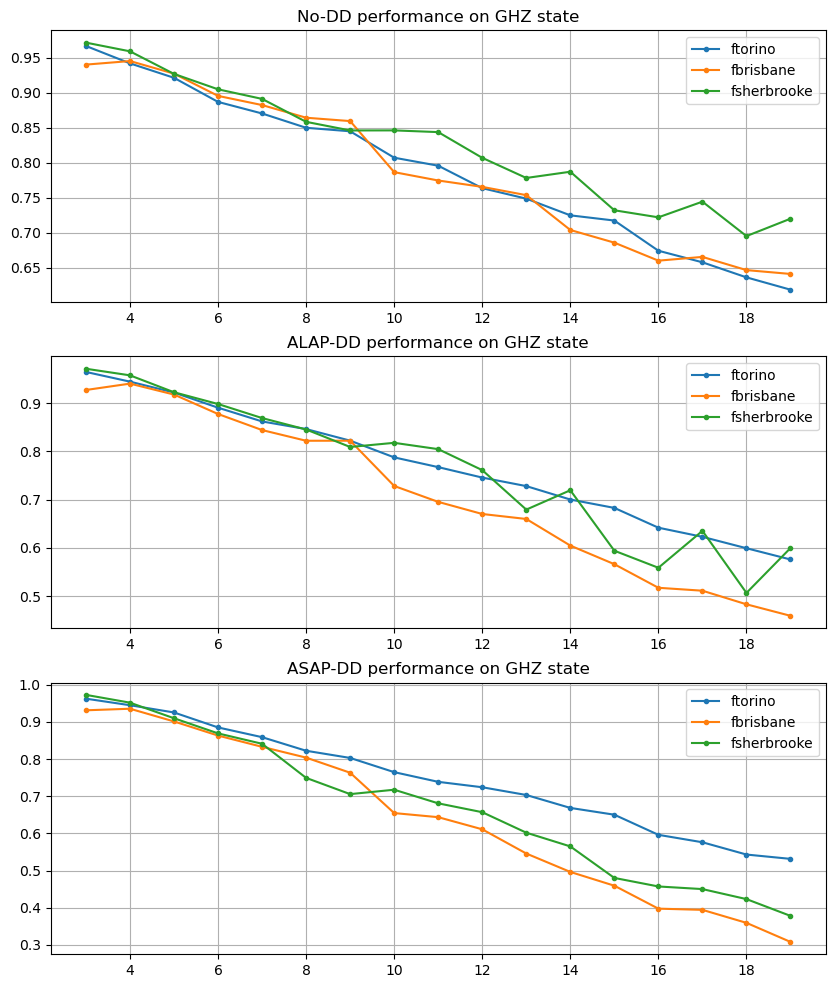

In [33]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(10, 12))

for col in ["ftorino", "fbrisbane", "fsherbrooke"]:
    for i in range(3):
        ax[i].plot(df.qubits, [item[i] for item in df[col]], label=col, marker='.')
    



ax[0].set_title("No-DD performance on GHZ state")
ax[1].set_title("ALAP-DD performance on GHZ state")
ax[2].set_title("ASAP-DD performance on GHZ state")

for item_axes in ax:

    item_axes.legend()
    item_axes.grid(True)




In [34]:
def check_dd(item):
    result = 'failed'

    if item[0] < item[1] or item[0] < item[2]:
        result = 'success'

    return result
    

backends_list = ["ftorino", "fbrisbane", "fsherbrooke"]

for backend in backends_list:
    df['dd_'+backend] = [check_dd(item) for item in df[backend]]

df


,qubits,ftorino,fbrisbane,fsherbrooke,dd_ftorino,dd_fbrisbane,dd_fsherbrooke
0,3,"(0.96650390625, 0.96474609375, 0.96220703125)","(0.93994140625, 0.9273437499999999, 0.93095703...","(0.9712890625, 0.97138671875, 0.9724609375)",failed,failed,success
1,4,"(0.94169921875, 0.94462890625, 0.94462890625)","(0.94501953125, 0.94052734375, 0.9351562499999...","(0.95888671875, 0.95771484375, 0.95146484375)",success,failed,failed
2,5,"(0.92109375, 0.9220703125, 0.92509765625)","(0.92705078125, 0.91787109375, 0.9009765624999...","(0.92666015625, 0.92265625, 0.9095703125)",success,failed,failed
3,6,"(0.88671875, 0.890625, 0.88486328125)","(0.8953125, 0.8775390624999999, 0.86298828125)","(0.9046875, 0.8982421875, 0.86884765625)",success,failed,failed
4,7,"(0.8702148437499999, 0.862109375, 0.85869140625)","(0.8822265625, 0.84423828125, 0.83271484375)","(0.891015625, 0.869140625, 0.84091796875)",failed,failed,failed
5,8,"(0.8498046875, 0.8462890625, 0.8221679687500001)","(0.86416015625, 0.8220703125, 0.8037109375)","(0.85830078125, 0.84541015625, 0.74921875)",failed,failed,failed
6,9,"(0.84482421875, 0.822265625, 0.8028320312499999)","(0.859375, 0.82216796875, 0.7630859375000001)","(0.84599609375, 0.8091796875, 0.70556640625)",failed,failed,failed
7,10,"(0.80712890625, 0.78759765625, 0.7646484375)","(0.7865234375000001, 0.7283203125, 0.65458984375)","(0.84609375, 0.8177734375, 0.7173828124999999)",failed,failed,failed
8,11,"(0.795703125, 0.7673828125, 0.73857421875)","(0.774609375, 0.6953125, 0.6435546875)","(0.8436523437500001, 0.8046875, 0.68076171875)",failed,failed,failed
9,12,"(0.763671875, 0.745703125, 0.7240234375)","(0.7655273437500001, 0.67021484375, 0.6109375)","(0.80693359375, 0.7611328125, 0.65693359375)",failed,failed,failed


In [45]:
for i in range(3, 20):
    for backend in backends_list:
        file_name = "GHZ-"+str(i)+"-"+backend+"-XX-DD.csv"
        small_df = pd.read_csv(file_name)
        small_df = small_df.rename(columns={'Unnamed: 0':'methods'})
        small_df.fillna('None', inplace=True)
        small_df.to_csv(file_name, index=False)
        del small_df




In [ ]:
def get_dataframe(qubit:int, backend:str):
    name = "GHZ-"+str(qubit)+"-"+backend+"-XX-DD.csv"
    df = pd.read_csv(name)
    return df


